# Experiment configuration

## Logging config

In [1]:
import logging

logging.basicConfig(
    level=logging.WARNING,
    format="%(asctime)s [%(levelname)s] %(module)s.%(funcName)s(): %(message)s"
)
logger = logging.getLogger(__name__)

## Native imports

In [2]:
from pathlib import Path
from pprint import pprint
from copy import copy

## Helper imports

In [3]:
from constants import *
from experiments_helpers import (
    make_uncertain_eval_function,
    make_evaluation_function,
    make_repeated_evaluation_function,
)

## FJSSP-W configuration

### FJSSP-W Problem imports

In [4]:
from util.uncertainty import create_uncertainty_vector
from util.benchmark_parser import WorkerBenchmarkParser

### FJSSP-W Solver imports

In [5]:
from fjsspw_solver import (
    Individual,
    Encoding,
)
from fjsspw_solver.operators import Mutations
from fjsspw_solver.GA_LS import (
    Method as LSMethod,
    MethodParams as LSMethodParams,
)

### FJSSP-W Method Params

In [6]:
base_ls_method_params = LSMethodParams.from_file(ROOT / "config/method_LS.cfg")

### FJSSP-W instance configuration

In [7]:
parser = WorkerBenchmarkParser()
instance_name = base_ls_method_params.instance_name

encoding = parser.parse_benchmark(INSTANCE_FJSSPW_PATH / f'{instance_name}')
encoding = Encoding(encoding.durations(), encoding.job_sequence())

### FJSSP-W evaluation functions

In [8]:
uncertainty_parameters = create_uncertainty_vector(encoding.n_operations(), factor=10.0, offset=1.0)
uncertain_eval_function = make_uncertain_eval_function(uncertainty_parameters)
evaluate_method = make_evaluation_function(LSMethod, uncertain_eval_function)
repeated_evaluate_method = make_repeated_evaluation_function(LSMethod, uncertain_eval_function)

# Local search experiments

## Prepare experiment

In [9]:
pprint(base_ls_method_params)

MethodParams(fitness_fun_evals=5000000,
             fitness_fun_evals_per_indv=3,
             local_search_mutation_params=MutationParams(reset_period=100,
                                                         mutation=<Mutations.WORKER_SWAP: (2,)>,
                                                         mutation_prob=0.1,
                                                         gene_swap_prob=0.0,
                                                         machine_swap_prob=0.0,
                                                         worker_swap_prob=0.0),
             local_search_interval=100,
             local_search_size=3,
             local_search_iterations=50,
             local_search_starting_temperature=1000.0,
             local_search_end_temperature=1.0,
             local_search_cooling_coefficient=0.95,
             generations=100,
             population_size=20,
             selection_params=SelectionParams(reset_period=100,
                                    

## Experiment 1

MethodParams(fitness_fun_evals=5000000,
             fitness_fun_evals_per_indv=3,
             local_search_mutation_params=MutationParams(reset_period=100,
                                                         mutation=<Mutations.WORKER_SWAP: (2,)>,
                                                         mutation_prob=0.1,
                                                         gene_swap_prob=0.0,
                                                         machine_swap_prob=0.0,
                                                         worker_swap_prob=0.0),
             local_search_interval=100,
             local_search_size=3,
             local_search_iterations=50,
             local_search_starting_temperature=1000.0,
             local_search_end_temperature=1.0,
             local_search_cooling_coefficient=0.95,
             generations=100,
             population_size=20,
             selection_params=SelectionParams(reset_period=100,
                                    

Solving: 100%|██████████| 100/100 [00:05<00:00, 19.42it/s]

([3, 3, 1, 9, 5, 2, 8, 3, 0, 7, 10, 0, 1, 9, 11, 3, 4, 2, 7, 8, 0, 5, 5, 9, 2, 10, 4, 5, 7, 6, 6, 8, 1, 11, 10, 11, 4, 4, 6, 0, 9, 10, 8, 1, 2, 6, 7, 11], [2, 1, 3, 7, 0, 1, 6, 7, 0, 3, 4, 5, 0, 4, 5, 5, 0, 4, 1, 7, 1, 2, 5, 3, 1, 4, 4, 4, 2, 4, 4, 6, 2, 3, 6, 5, 3, 4, 6, 7, 1, 2, 6, 5, 1, 2, 4, 7], [9, 1, 7, 5, 7, 9, 5, 5, 10, 9, 2, 4, 7, 3, 9, 11, 10, 6, 8, 4, 6, 3, 11, 8, 3, 1, 3, 4, 4, 6, 2, 7, 2, 4, 10, 8, 1, 5, 5, 8, 11, 9, 7, 0, 0, 0, 3, 7], [147, 293, 805, 1001, 79, 429, 854, 1314, 295, 496, 826, 923, 0, 79, 268, 399, 381, 923, 1053, 1158, 0, 484, 604, 940, 889, 1125, 1418, 1574, 244, 545, 966, 1125, 0, 600, 805, 1241, 0, 268, 545, 717, 144, 604, 1001, 1101, 496, 889, 1279, 1449], [244, 429, 940, 1132, 295, 496, 1001, 1449, 381, 600, 923, 1084, 79, 268, 399, 585, 503, 966, 1158, 1314, 144, 604, 841, 1053, 1044, 1279, 1574, 1720, 484, 826, 1125, 1262, 147, 805, 854, 1376, 232, 545, 717, 853, 293, 773, 1055, 1241, 889, 1101, 1418, 1697])


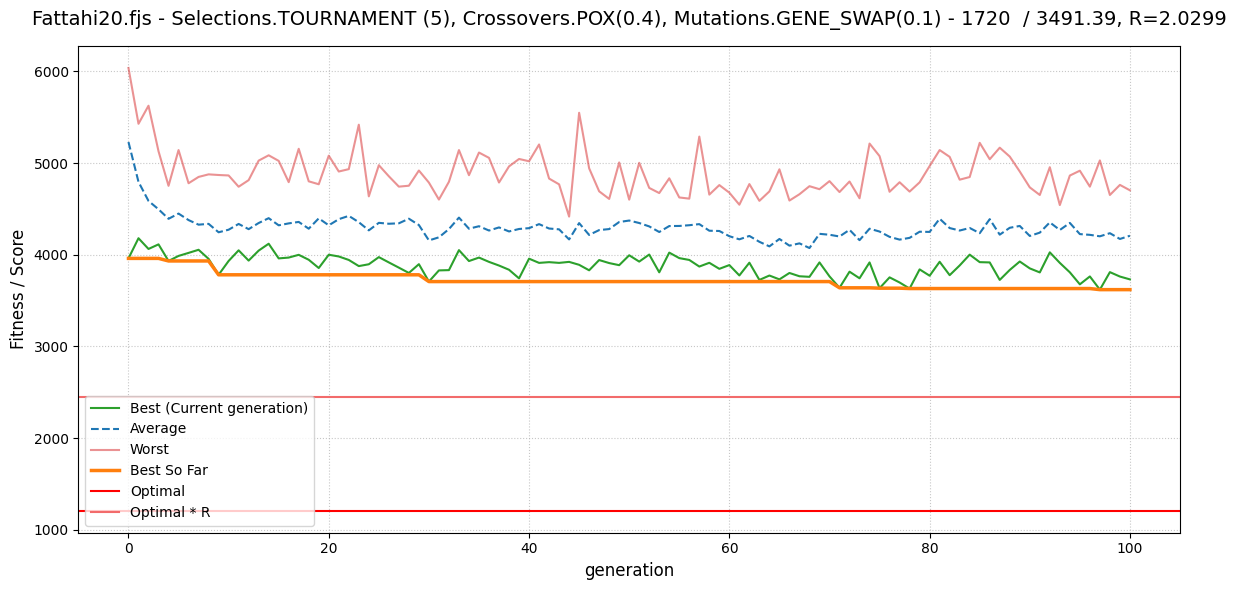

In [10]:
ls_method_params = copy(base_ls_method_params)
pprint(ls_method_params)

evaluate_method(ls_method_params, encoding)

## Experiment 2

MethodParams(fitness_fun_evals=5000000,
             fitness_fun_evals_per_indv=3,
             local_search_mutation_params=MutationParams(reset_period=100,
                                                         mutation=<Mutations.WORKER_SWAP: (2,)>,
                                                         mutation_prob=0.1,
                                                         gene_swap_prob=0.0,
                                                         machine_swap_prob=0.0,
                                                         worker_swap_prob=0.0),
             local_search_interval=1,
             local_search_size=1,
             local_search_iterations=10000,
             local_search_starting_temperature=2000,
             local_search_end_temperature=10,
             local_search_cooling_coefficient=0.95,
             generations=1,
             population_size=1,
             selection_params=SelectionParams(reset_period=100,
                                         

Solving:   0%|          | 0/1 [00:00<?, ?it/s]

Solving: 100%|██████████| 1/1 [00:00<00:00,  3.67it/s]

([4, 4, 3, 8, 2, 11, 9, 5, 6, 11, 3, 7, 9, 11, 10, 1, 4, 7, 3, 4, 1, 3, 6, 8, 5, 0, 1, 7, 7, 0, 8, 5, 10, 6, 5, 2, 8, 2, 9, 10, 0, 11, 2, 0, 10, 6, 9, 1], [0, 1, 4, 6, 0, 1, 4, 7, 1, 3, 5, 5, 1, 2, 5, 5, 1, 4, 4, 5, 1, 2, 5, 3, 1, 2, 5, 4, 2, 4, 4, 6, 2, 2, 4, 7, 3, 4, 5, 6, 1, 2, 6, 5, 1, 4, 5, 7], [2, 11, 6, 3, 7, 0, 11, 0, 5, 0, 10, 3, 7, 11, 6, 4, 2, 7, 7, 6, 1, 6, 0, 11, 9, 5, 5, 4, 6, 1, 2, 8, 6, 3, 4, 0, 5, 5, 0, 9, 2, 2, 7, 6, 6, 2, 7, 7], [1131, 1618, 1820, 2013, 238, 1131, 1439, 2015, 238, 303, 408, 755, 168, 238, 1096, 1419, 0, 119, 1096, 1240, 673, 1419, 1603, 1840, 816, 980, 1840, 2016, 673, 1197, 1618, 1777, 0, 1111, 1777, 1840, 0, 303, 580, 980, 980, 1777, 1959, 2016, 303, 673, 926, 1197], [1367, 1742, 1971, 2241, 454, 1191, 1618, 2175, 303, 408, 572, 912, 238, 492, 1240, 1603, 119, 168, 1197, 1419, 816, 1538, 1840, 1968, 980, 1111, 2016, 2162, 906, 1439, 1777, 1927, 139, 1299, 1820, 2015, 224, 580, 755, 1145, 1131, 1959, 2013, 2153, 673, 926, 1096, 1445])


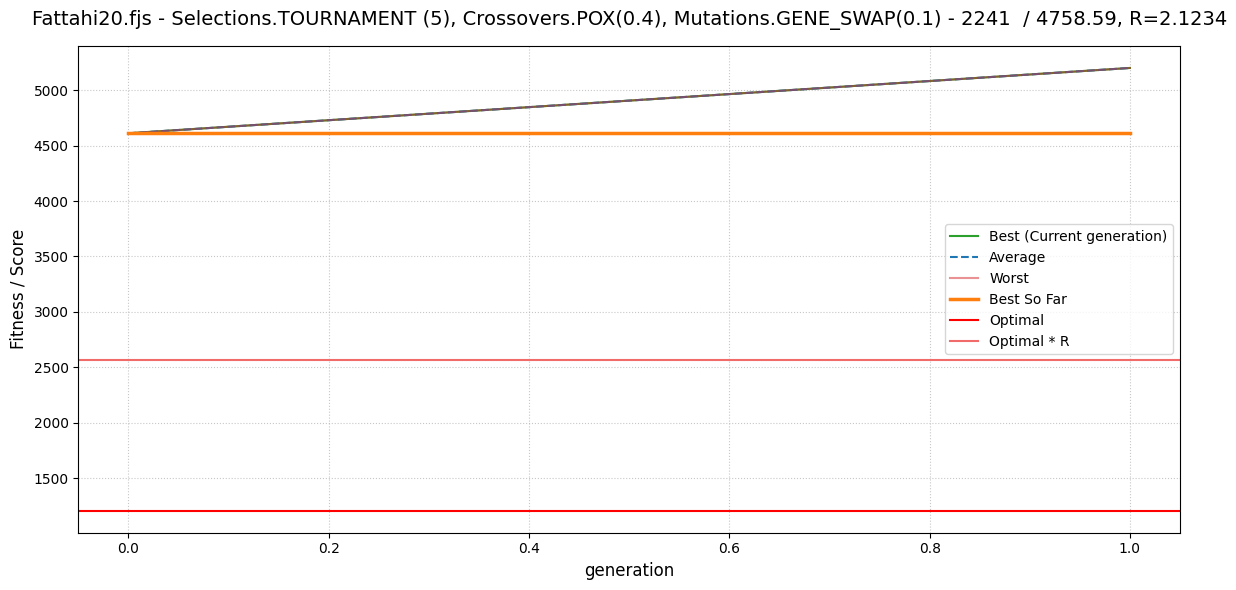

In [11]:
ls_method_params = copy(base_ls_method_params)
ls_method_params.update(
    generations=1,
    local_search_interval=1,
    local_search_size=1,
    local_search_iterations=10000,
    local_search_starting_temperature=2000,
    local_search_end_temperature=10,
    local_search_cooling_coefficient=0.95,
    population_size=1,
)
pprint(ls_method_params)

evaluate_method(ls_method_params, encoding)

## Experiment 3

MethodParams(fitness_fun_evals=5000000,
             fitness_fun_evals_per_indv=3,
             local_search_mutation_params=MutationParams(reset_period=100,
                                                         mutation=<Mutations.WORKER_SWAP: (2,)>,
                                                         mutation_prob=0.1,
                                                         gene_swap_prob=0.0,
                                                         machine_swap_prob=0.0,
                                                         worker_swap_prob=0.0),
             local_search_interval=10,
             local_search_size=1,
             local_search_iterations=10000,
             local_search_starting_temperature=2000,
             local_search_end_temperature=10,
             local_search_cooling_coefficient=0.95,
             generations=100,
             population_size=10,
             selection_params=SelectionParams(reset_period=100,
                                     

Solving: 100%|██████████| 100/100 [00:04<00:00, 20.92it/s]

([9, 4, 6, 6, 7, 4, 2, 6, 3, 0, 9, 7, 9, 0, 7, 8, 8, 11, 1, 11, 3, 2, 5, 2, 0, 6, 10, 11, 10, 7, 9, 1, 0, 1, 11, 4, 5, 3, 10, 5, 1, 5, 10, 8, 3, 4, 8, 2], [2, 1, 6, 7, 2, 1, 4, 7, 1, 3, 5, 5, 0, 2, 3, 5, 1, 4, 4, 7, 1, 3, 6, 3, 1, 4, 6, 7, 2, 4, 5, 6, 2, 3, 6, 5, 3, 4, 6, 7, 1, 2, 6, 5, 1, 4, 5, 7], [10, 5, 5, 8, 2, 8, 0, 4, 5, 7, 11, 11, 10, 11, 11, 9, 6, 7, 7, 2, 8, 4, 2, 7, 1, 1, 4, 4, 3, 0, 3, 3, 2, 10, 4, 5, 6, 9, 11, 5, 9, 10, 0, 0, 3, 10, 9, 11], [253, 368, 857, 1217, 502, 1127, 1217, 1628, 154, 236, 348, 511, 0, 857, 1111, 1602, 236, 368, 1401, 1779, 831, 966, 1462, 1651, 0, 154, 308, 487, 0, 682, 947, 1098, 355, 502, 1252, 1758, 0, 417, 682, 1071, 966, 1217, 1412, 1462, 507, 947, 1217, 1398], [355, 507, 1071, 1358, 640, 1197, 1401, 1779, 219, 348, 511, 668, 91, 1111, 1256, 1758, 368, 417, 1502, 1936, 966, 1105, 1651, 1767, 154, 308, 487, 698, 253, 947, 1098, 1252, 502, 731, 1300, 1918, 236, 682, 857, 1217, 1127, 1412, 1462, 1602, 831, 1217, 1398, 1628])


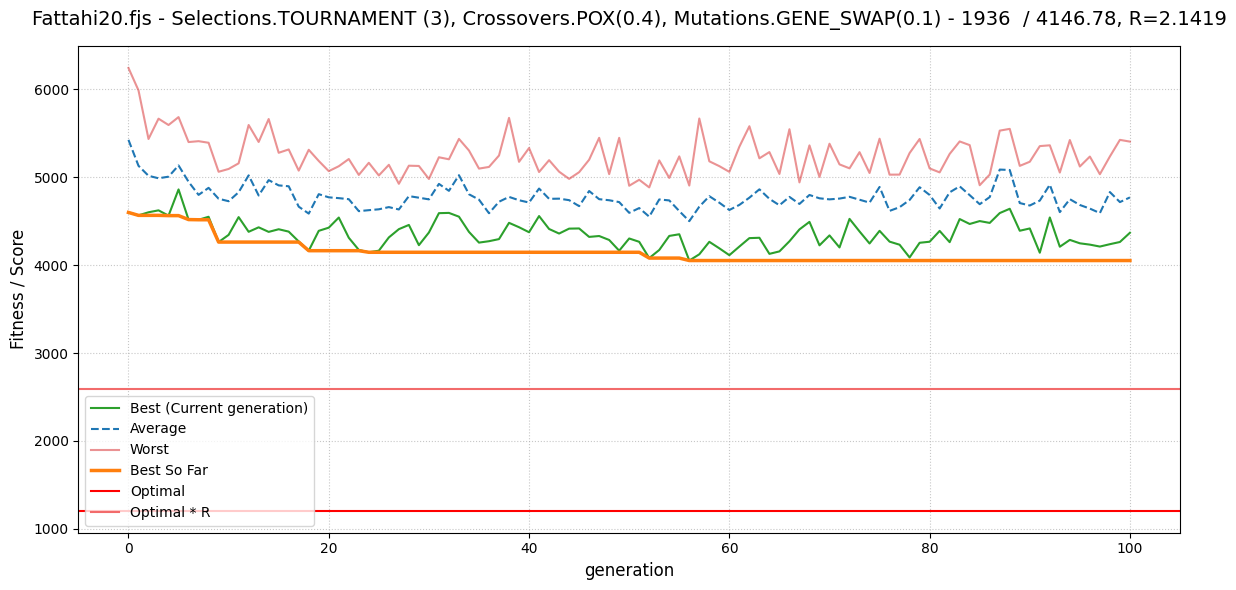

In [12]:
ls_method_params = copy(base_ls_method_params)
ls_method_params.update(
    generations=100,
    population_size=10,
    local_search_interval=10,
    local_search_size=1,
    local_search_iterations=10000,
    local_search_starting_temperature=2000,
    local_search_end_temperature=10,
    local_search_cooling_coefficient=0.95,
)
ls_method_params.selection_params.update(
    size=3
)
ls_method_params.crossover_params.update(
    crossover_prob=0.4
)
ls_method_params.mutation_params.update(
    mutation=Mutations.GENE_SWAP,
    mutation_prob=0.1
)
pprint(ls_method_params)

evaluate_method(ls_method_params, encoding)

## Experiment 4

MethodParams(fitness_fun_evals=5000000,
             fitness_fun_evals_per_indv=3,
             local_search_mutation_params=MutationParams(reset_period=100,
                                                         mutation=<Mutations.WORKER_SWAP: (2,)>,
                                                         mutation_prob=0.1,
                                                         gene_swap_prob=0.0,
                                                         machine_swap_prob=0.0,
                                                         worker_swap_prob=0.0),
             local_search_interval=25,
             local_search_size=1,
             local_search_iterations=10000,
             local_search_starting_temperature=2000,
             local_search_end_temperature=10,
             local_search_cooling_coefficient=0.95,
             generations=200,
             population_size=20,
             selection_params=SelectionParams(reset_period=100,
                                     

Solving: 100%|██████████| 200/200 [00:11<00:00, 17.43it/s]

([2, 4, 9, 9, 3, 9, 6, 5, 11, 8, 7, 6, 5, 3, 3, 9, 0, 1, 4, 10, 6, 2, 11, 10, 3, 11, 6, 0, 2, 0, 7, 0, 8, 10, 8, 11, 4, 7, 1, 10, 1, 8, 5, 5, 7, 4, 2, 1], [1, 3, 6, 7, 0, 1, 6, 4, 0, 2, 3, 5, 0, 4, 5, 5, 1, 3, 5, 7, 3, 3, 5, 3, 1, 2, 4, 7, 2, 4, 4, 6, 1, 2, 4, 7, 3, 5, 6, 7, 2, 2, 6, 5, 1, 4, 4, 7], [2, 7, 10, 5, 3, 8, 5, 0, 10, 9, 6, 2, 5, 3, 7, 5, 4, 8, 4, 1, 8, 4, 8, 7, 7, 0, 10, 3, 0, 5, 2, 8, 9, 11, 4, 7, 2, 1, 2, 7, 7, 2, 2, 0, 4, 10, 4, 3], [770, 981, 1124, 1310, 367, 981, 1441, 1588, 0, 412, 747, 1541, 86, 178, 468, 616, 0, 394, 781, 1608, 237, 608, 1051, 1313, 116, 280, 412, 787, 0, 1015, 1382, 1588, 608, 1163, 1339, 1441, 0, 237, 468, 635, 787, 981, 1310, 1362, 280, 608, 878, 1035], [981, 1124, 1310, 1441, 586, 1051, 1588, 1712, 86, 577, 929, 1728, 178, 367, 616, 781, 116, 463, 865, 1765, 394, 747, 1313, 1429, 280, 412, 558, 1035, 274, 1280, 1541, 1738, 770, 1339, 1382, 1608, 237, 468, 635, 787, 935, 1163, 1362, 1502, 608, 878, 1015, 1253])


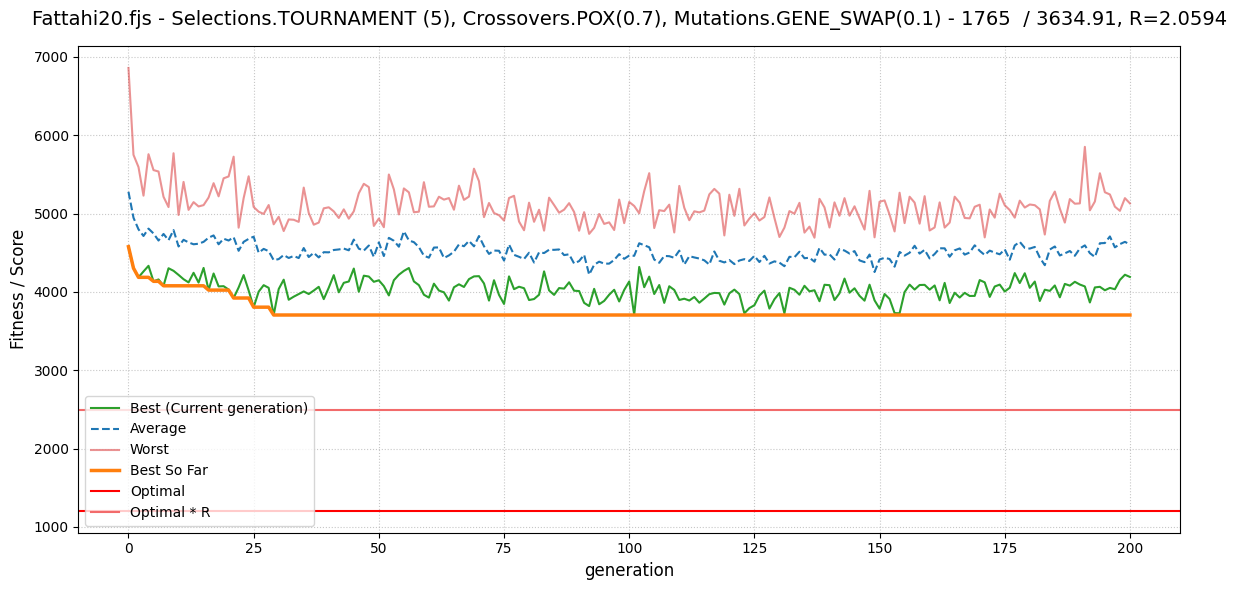

In [13]:
ls_method_params = copy(base_ls_method_params)
ls_method_params.update(
    generations=200,
    population_size=20,
    local_search_interval=25,
    local_search_size=1,
    local_search_iterations=10000,
    local_search_starting_temperature=2000,
    local_search_end_temperature=10,
    local_search_cooling_coefficient=0.95,
)
ls_method_params.selection_params.update(
    size=5
)
ls_method_params.crossover_params.update(
    crossover_prob=0.7
)
ls_method_params.mutation_params.update(
    mutation=Mutations.GENE_SWAP,
    mutation_prob=0.1
)
pprint(ls_method_params)

evaluate_method(ls_method_params, encoding)

## Experiment 5

MethodParams(fitness_fun_evals=5000000,
             fitness_fun_evals_per_indv=3,
             local_search_mutation_params=MutationParams(reset_period=100,
                                                         mutation=<Mutations.WORKER_SWAP: (2,)>,
                                                         mutation_prob=0.1,
                                                         gene_swap_prob=0.0,
                                                         machine_swap_prob=0.0,
                                                         worker_swap_prob=0.0),
             local_search_interval=25,
             local_search_size=1,
             local_search_iterations=100000,
             local_search_starting_temperature=2000,
             local_search_end_temperature=5,
             local_search_cooling_coefficient=0.95,
             generations=200,
             population_size=20,
             selection_params=SelectionParams(reset_period=100,
                                     

Solving: 100%|██████████| 200/200 [00:11<00:00, 17.00it/s]

([10, 11, 11, 4, 4, 9, 8, 7, 0, 9, 6, 9, 2, 5, 2, 8, 1, 2, 3, 9, 1, 10, 6, 3, 8, 7, 2, 10, 4, 4, 6, 6, 11, 5, 1, 0, 3, 7, 3, 5, 8, 11, 10, 5, 1, 7, 0, 0], [2, 1, 6, 7, 0, 1, 4, 4, 0, 3, 5, 5, 1, 2, 3, 5, 1, 4, 5, 7, 1, 2, 4, 3, 1, 2, 4, 7, 2, 4, 5, 6, 1, 2, 6, 5, 3, 4, 4, 7, 1, 3, 6, 5, 1, 2, 6, 7], [9, 2, 10, 4, 7, 3, 0, 0, 6, 10, 10, 3, 7, 5, 11, 8, 5, 10, 0, 10, 10, 6, 6, 7, 7, 1, 10, 2, 3, 0, 5, 6, 7, 5, 11, 6, 9, 10, 0, 7, 10, 2, 2, 5, 4, 9, 4, 4], [253, 1182, 1425, 1638, 94, 1114, 1208, 1625, 0, 640, 737, 901, 1044, 1114, 1385, 1553, 468, 595, 1062, 1266, 902, 1385, 1504, 1625, 738, 921, 1062, 1425, 0, 797, 1385, 1625, 595, 738, 921, 1151, 0, 236, 640, 1114, 0, 236, 441, 595, 140, 468, 675, 846], [350, 1314, 1611, 1793, 310, 1182, 1392, 1749, 94, 737, 901, 1058, 1114, 1385, 1530, 1712, 595, 640, 1151, 1425, 1044, 1504, 1625, 1741, 902, 1054, 1208, 1638, 253, 1062, 1553, 1784, 738, 921, 970, 1309, 236, 517, 797, 1266, 140, 441, 493, 735, 468, 675, 846, 1091])


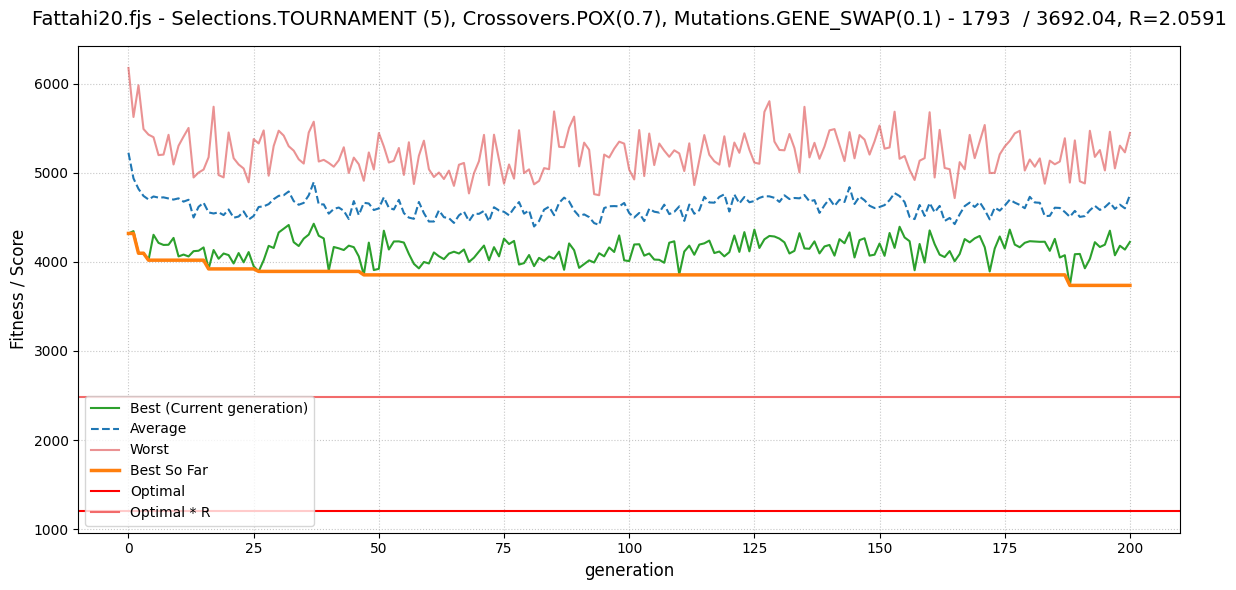

In [14]:
ls_method_params = copy(base_ls_method_params)
ls_method_params.update(
    generations=200,
    population_size=20,
    local_search_interval=25,
    local_search_size=1,
    local_search_iterations=100000,
    local_search_starting_temperature=2000,
    local_search_end_temperature=5,
    local_search_cooling_coefficient=0.95,
)
ls_method_params.selection_params.update(
    size=5
)
ls_method_params.crossover_params.update(
    crossover_prob=0.7
)
ls_method_params.mutation_params.update(
    mutation=Mutations.GENE_SWAP,
    mutation_prob=0.1
)
pprint(ls_method_params)

evaluate_method(ls_method_params, encoding)

Solving: 100%|██████████| 200/200 [00:12<00:00, 16.03it/s]


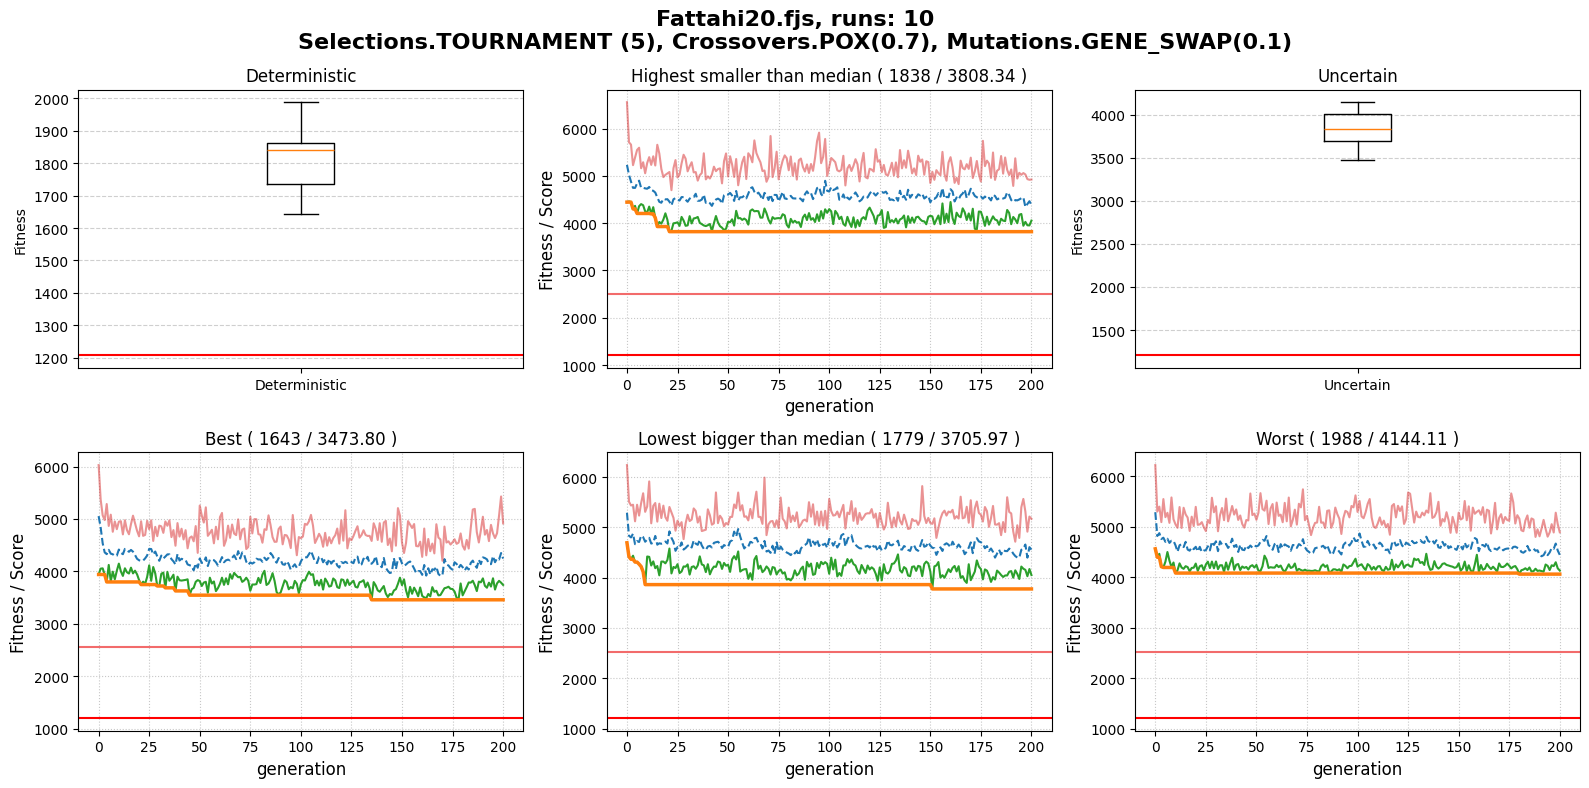

[(1779,
  3705.967024518817,
  WindowsPath('C:/Documents/University/Magisterka/FJSSP-W-Competition/logs/Method_Fattahi20.fjs_274.csv')),
 (1988,
  4144.108998319498,
  WindowsPath('C:/Documents/University/Magisterka/FJSSP-W-Competition/logs/Method_Fattahi20.fjs_275.csv')),
 (1864,
  3943.9550387485538,
  WindowsPath('C:/Documents/University/Magisterka/FJSSP-W-Competition/logs/Method_Fattahi20.fjs_276.csv')),
 (1838,
  3808.3382329063234,
  WindowsPath('C:/Documents/University/Magisterka/FJSSP-W-Competition/logs/Method_Fattahi20.fjs_277.csv')),
 (1643,
  3473.8035375360273,
  WindowsPath('C:/Documents/University/Magisterka/FJSSP-W-Competition/logs/Method_Fattahi20.fjs_278.csv')),
 (1855,
  3868.7751315224095,
  WindowsPath('C:/Documents/University/Magisterka/FJSSP-W-Competition/logs/Method_Fattahi20.fjs_279.csv')),
 (1914,
  4038.600877586792,
  WindowsPath('C:/Documents/University/Magisterka/FJSSP-W-Competition/logs/Method_Fattahi20.fjs_280.csv')),
 (1665,
  3615.1156415715527,
  Windo

In [15]:
repeated_evaluate_method(ls_method_params, encoding, 10)